**1. Download data:**

In [1]:
%%bash
mkdir -p homework_data

# 1. inter-station distances in 2022
curl -o homework_data/inter-station-distances-2022-01.csv https://opendata.rijdendetreinen.nl/public/tariff-distances/tariff-distances-2022-01.csv

# 2. railway stations in 2023
curl -o homework_data/stations-2023-09.csv https://opendata.rijdendetreinen.nl/public/stations/stations-2023-09.csv

# 3. train disruptions between 2011 and 2023
for year in $(seq 2011 2023); do
  curl -o homework_data/disruptions-${year}.csv https://opendata.rijdendetreinen.nl/public/disruptions/disruptions-${year}.csv
done

# 4. train services between 2019 and 2025
for year in $(seq 2019 2025); do
  curl -o homework_data/services-${year}.csv.gz https://opendata.rijdendetreinen.nl/public/services/services-${year}.csv.gz
done

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  569k  100  569k    0     0  3982k      0 --:--:-- --:--:-- --:--:-- 3985k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 65007  100 65007    0     0  1013k      0 --:--:-- --:--:-- --:--:-- 1023k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  400k  100  400k    0     0  4284k      0 --:--:-- --:--:-- --:--:-- 4306k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  464k  100  464k    0     0  4831k      0 --:--:-- --:--:-- --:--:-- 4834k
  % Total    % Received % Xferd  Average Speed   Tim

**2. Put stations data into stations table in DuckDB. This changes rarely, so we treat it as a almost constant file.**

In [2]:
import duckdb

db = duckdb.connect("homework_data/trains.db")

db.sql("""
CREATE TABLE IF NOT EXISTS stations AS
FROM 'homework_data/stations-2023-09.csv'
""")

db.sql("DESCRIBE stations")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ uic         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name_short  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_medium │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_long   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ slug        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ type        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lat     │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lng     │ DOUB

**3. create tables distances and distances_long. We treat this similarly to stations table.**

In [3]:
db.sql("""
CREATE TABLE IF NOT EXISTS distances AS
    FROM read_csv(
        'homework_data/inter-station-distances-2022-01.csv',
        nullstr = 'XXX'
    );
""")

db.sql("""
FROM (DESCRIBE distances)
LIMIT 5;""")


┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [4]:
db.sql("""
CREATE TABLE IF NOT EXISTS distances_long AS
    UNPIVOT distances
    ON COLUMNS (* EXCLUDE station)
    INTO NAME other_station VALUE distance;
""")

db.sql("""
FROM (DESCRIBE distances)
LIMIT 5;""")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [5]:
db.sql("DESCRIBE distances")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AHZ         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AKL         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ AKM         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ ALM         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ ALMB        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│  ·          │   · 

In [6]:
db.sql("DESCRIBE distances_long")

┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ other_station │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ distance      │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

**4. Put train disruptions into disruptions table in the Postgres database. We expect this data to change regularly, and thus treat it as a typical OLTP table.**

In [7]:
# install and import extension
db.sql("""INSTALL postgres; LOAD postgres;""")

# NEVER write password like this explicitly in real code!
conn_string = "host=localhost user=postgres password=postgres dbname=postgres"

# note that we create the alias for this Postgres database here
# this also needs to be in single quotes
db.sql(f"""
ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
""")


db.sql("""
CREATE TABLE IF NOT EXISTS postgres_db.disruptions AS
SELECT * FROM read_csv('homework_data/disruptions-*.csv', union_by_name=true)
""")

In [8]:
db.sql("""
SELECT YEAR(start_time) AS year,
       COUNT(*) AS num_disruptions
FROM postgres_db.disruptions
GROUP BY year
ORDER BY year
""")

┌───────┬─────────────────┐
│ year  │ num_disruptions │
│ int64 │      int64      │
├───────┼─────────────────┤
│  2011 │            1846 │
│  2012 │            2074 │
│  2013 │            2312 │
│  2014 │            2484 │
│  2015 │            2947 │
│  2016 │            3031 │
│  2017 │            4085 │
│  2018 │            5190 │
│  2019 │            5940 │
│  2020 │            4450 │
│  2021 │            4874 │
│  2022 │            5499 │
│  2023 │            5168 │
├───────┴─────────────────┤
│ 13 rows       2 columns │
└─────────────────────────┘

**5. Transform train services CSV files into a single Parquet file. Make table services from it. We treat this as a big data batch input, created rarely but regularly for analytics purposes.**

In [9]:
#Parquet with ZSTD compression
duckdb.sql("""
COPY (SELECT * FROM "homework_data/services-*.csv.gz") TO "homework_data/services_all.parquet" (FORMAT PARQUET, COMPRESSION ZSTD);
""")

db.sql("""
CREATE TABLE IF NOT EXISTS services AS
FROM read_parquet('homework_data/services_all.parquet')
""")

db.sql("DESCRIBE services")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │ column_type │  null   │   key   │ default │  extra  │
│           varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Partly cancelled     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Maximum delay        │ BIGINT    

**7. Queries**

In [10]:
db.sql("Describe services")

┌──────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │ column_type │  null   │   key   │ default │  extra  │
│           varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Partly cancelled     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Maximum delay        │ BIGINT    

In [11]:
#1 Czy na pewno chodziło o Amsterdam Central a nie Centraal jak w dokumentacji?
db.sql("""
SELECT "Stop:Station name", COUNT(*) AS trains_count_departure 
FROM services
WHERE "Stop:Station name" LIKE 'Amsterdam C%'
AND "Stop:Departure time" IS NOT NULL
GROUP BY "Stop:Station name";
""")


┌────────────────────┬────────────────────────┐
│ Stop:Station name  │ trains_count_departure │
│      varchar       │         int64          │
├────────────────────┼────────────────────────┤
│ Amsterdam Centraal │                1940873 │
└────────────────────┴────────────────────────┘

In [12]:
#Jeśli specjalnie miało być Amsterdam Central, to:
db.sql("""
SELECT COUNT(*) AS trains_count_departure
FROM services
WHERE "Stop:Station name" = 'Amsterdam Central'
  AND "Stop:Departure time" IS NOT NULL;
""")

┌────────────────────────┐
│ trains_count_departure │
│         int64          │
├────────────────────────┤
│                      0 │
└────────────────────────┘

In [13]:
#2
db.sql("""
SELECT "Service:Type",
        AVG("Stop:Arrival delay") AS avg_arrival_delay
FROM services
GROUP BY "Service:Type"
ORDER BY avg_arrival_delay DESC
""")

┌──────────────────────┬────────────────────┐
│     Service:Type     │ avg_arrival_delay  │
│       varchar        │       double       │
├──────────────────────┼────────────────────┤
│ Alpen Express        │  31.84254143646409 │
│ Krokus Express       │ 18.304347826086957 │
│ European Sleeper     │ 14.262589044460821 │
│ Nightjet             │   9.42391097403092 │
│ ICE                  │   7.76692176533566 │
│ Eurostar             │  7.302104678961749 │
│ ICE International    │  5.482790573052148 │
│ Thalys               │ 5.3961896909446025 │
│ Int. Trein           │  4.677560708417016 │
│ Nachttrein           │ 3.8370501214396113 │
│     ·                │                 ·  │
│     ·                │                 ·  │
│     ·                │                 ·  │
│ Tram i.p.v. trein    │                0.0 │
│ Niet instappen       │                0.0 │
│ Belbus ipv trein     │                0.0 │
│ Metro ipv trein      │                0.0 │
│ Metro i.p.v. trein   │          

In [14]:
db.sql("""
SELECT YEAR(start_time) AS year,
       MODE(cause_en) AS most_common_cause
FROM postgres_db.disruptions
GROUP BY year
ORDER BY year
""")

┌───────┬───────────────────┐
│ year  │ most_common_cause │
│ int64 │      varchar      │
├───────┼───────────────────┤
│  2011 │ broken down train │
│  2012 │ points failure    │
│  2013 │ points failure    │
│  2014 │ broken down train │
│  2015 │ broken down train │
│  2016 │ broken down train │
│  2017 │ broken down train │
│  2018 │ broken down train │
│  2019 │ broken down train │
│  2020 │ broken down train │
│  2021 │ broken down train │
│  2022 │ broken down train │
│  2023 │ broken down train │
├───────┴───────────────────┤
│ 13 rows         2 columns │
└───────────────────────────┘

In [15]:
#4
db.sql("""
SELECT COUNT(*) AS trains_started_in_amsterdam
FROM services
WHERE "Stop:Station name" LIKE 'Amsterdam%'
  AND "Stop:Arrival time" IS NULL
""")

┌─────────────────────────────┐
│ trains_started_in_amsterdam │
│            int64            │
├─────────────────────────────┤
│                     1287387 │
└─────────────────────────────┘

In [16]:
#5
db.sql("""
SELECT AVG(CASE WHEN s.country != 'NL' THEN 1.0 ELSE 0.0 END) AS fraction_outside_nl
FROM services svc
JOIN stations s ON svc."Stop:Station code" = s.code
WHERE svc."Stop:Departure time" IS NULL
""")

┌─────────────────────┐
│ fraction_outside_nl │
│       double        │
├─────────────────────┤
│ 0.03803741997174202 │
└─────────────────────┘

In [17]:
#6
db.sql("""
SELECT s1.name_long AS station1,
       s2.name_long AS station2,
       dl.distance
FROM distances_long dl
JOIN stations s1 ON dl.station = s1.code
JOIN stations s2 ON dl.other_station = s2.code
WHERE s1.country = 'NL'
  AND s2.country = 'NL'
  AND dl.station < dl.other_station
ORDER BY dl.distance DESC
LIMIT 1
""")

┌───────────┬────────────┬──────────┐
│ station1  │  station2  │ distance │
│  varchar  │  varchar   │  int64   │
├───────────┼────────────┼──────────┤
│ Eemshaven │ Vlissingen │      426 │
└───────────┴────────────┴──────────┘

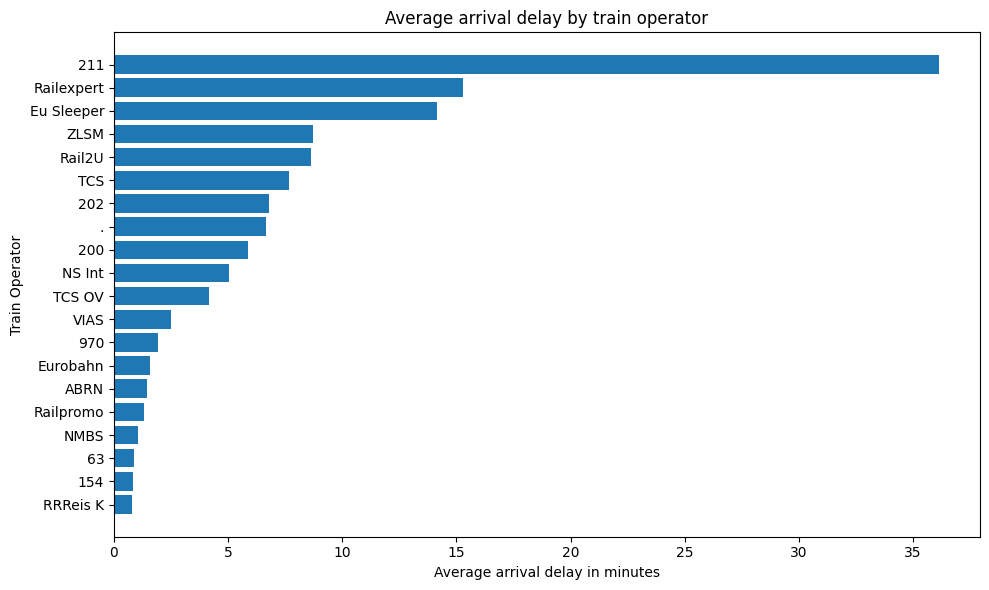

In [18]:
#7
#KOMENTARZ: Z uwagi na dużą liczbę operatorów, zdecydowałem się ograniczyć wyniki do 20 najważniejszych
# aby było to czytelniejsze na wykresie.
import matplotlib.pyplot as plt

df = db.sql("""
SELECT "Service:Company" AS company,
       AVG("Stop:Arrival delay") AS avg_arrival_delay
FROM services
GROUP BY company
ORDER BY avg_arrival_delay DESC
LIMIT 20
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df["company"], df["avg_arrival_delay"])
ax.set_xlabel("Average arrival delay in minutes")
ax.set_ylabel("Train Operator")
ax.set_title("Average arrival delay by train operator")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

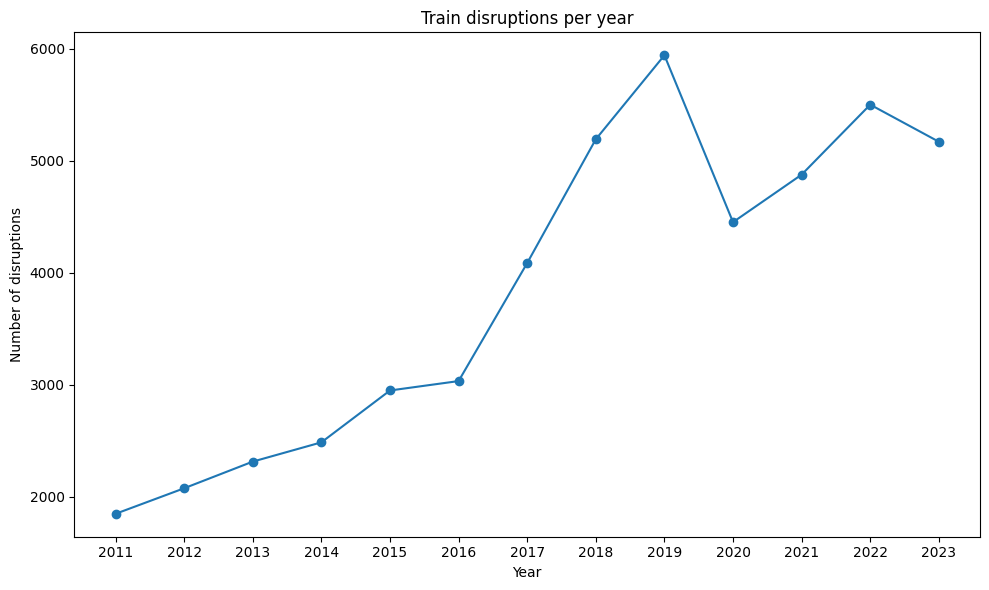

In [19]:
#8
df = db.sql("""
SELECT YEAR(start_time) AS year,
       COUNT(*) AS num_disruptions
FROM postgres_db.disruptions
GROUP BY year
ORDER BY year
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["year"], df["num_disruptions"], marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Number of disruptions")
ax.set_title("Train disruptions per year")
ax.set_xticks(df["year"])
plt.tight_layout()
plt.show()

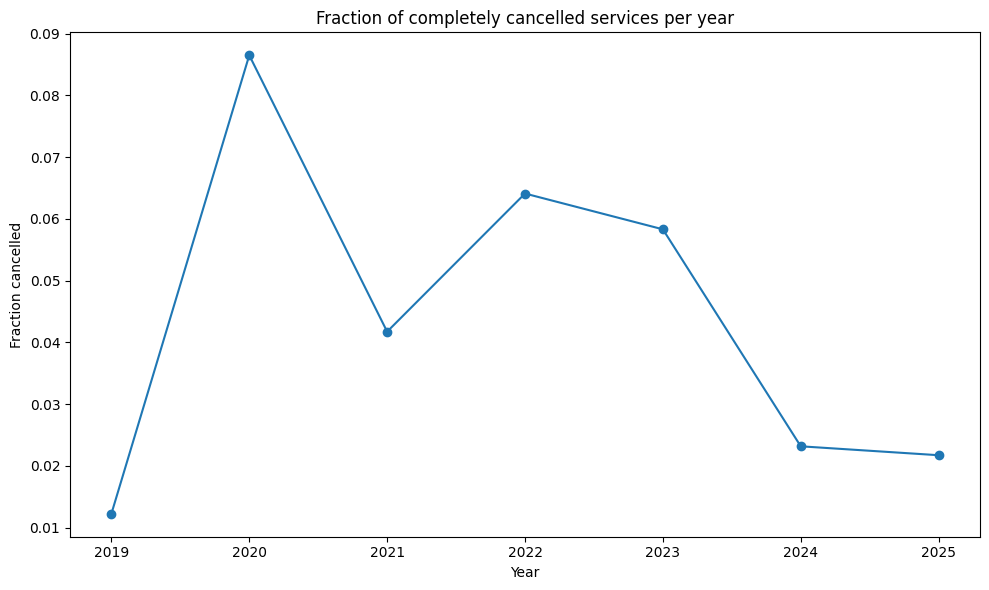

In [20]:
#9. 
df = db.sql("""
SELECT YEAR("Service:Date") AS year,
       AVG(CASE WHEN "Service:Completely cancelled" THEN 1.0 ELSE 0.0 END) AS fraction_cancelled
FROM services
WHERE "Stop:Arrival time" IS NULL
GROUP BY year
ORDER BY year
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["year"], df["fraction_cancelled"], marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Fraction cancelled")
ax.set_title("Fraction of completely cancelled services per year")
ax.set_xticks(df["year"])
plt.tight_layout()
plt.show()

**8. `service` enhancements**

In [21]:
#1. 
db.sql("""
SELECT
    "Service:RDT-ID",
    "Stop:Station code" AS start_station_code,
    LEAD("Stop:Station code") OVER (
        PARTITION BY "Service:RDT-ID"
        ORDER BY "Stop:Departure time" NULLS LAST
    ) AS end_station_code
FROM services
WHERE "Service:RDT-ID" = (SELECT "Service:RDT-ID" FROM services LIMIT 1)
""")

┌────────────────┬────────────────────┬──────────────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │
│     int64      │      varchar       │     varchar      │
├────────────────┼────────────────────┼──────────────────┤
│         738804 │ RTD                │ DT               │
│         738804 │ DT                 │ GV               │
│         738804 │ GV                 │ LEDN             │
│         738804 │ LEDN               │ SHL              │
│         738804 │ SHL                │ ASD              │
│         738804 │ ASD                │ UT               │
│         738804 │ UT                 │ NULL             │
└────────────────┴────────────────────┴──────────────────┘

In [22]:
#1. 
db.sql("""
CREATE OR REPLACE TEMP TABLE service_pairs AS
SELECT
    "Service:RDT-ID",
    "Stop:Station code" AS start_station_code,
    LEAD("Stop:Station code") OVER (
        PARTITION BY "Service:RDT-ID"
        ORDER BY "Stop:Departure time" NULLS LAST
    ) AS end_station_code
FROM services
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [23]:
db.sql("FROM service_pairs LIMIT 10")


┌────────────────┬────────────────────┬──────────────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │
│     int64      │      varchar       │     varchar      │
├────────────────┼────────────────────┼──────────────────┤
│        4797080 │ MAS                │ UTZL             │
│        4797080 │ UTZL               │ UT               │
│        4797080 │ UT                 │ UTVR             │
│        4797080 │ UTVR               │ BNK              │
│        4797080 │ BNK                │ DB               │
│        4797080 │ DB                 │ MRN              │
│        4797080 │ MRN                │ VNDW             │
│        4797080 │ VNDW               │ VNDC             │
│        4797080 │ VNDC               │ RHN              │
│        4797080 │ RHN                │ NULL             │
├────────────────┴────────────────────┴──────────────────┤
│ 10 rows                                      3 columns │
└───────────────────────────────────────────────────────

In [24]:
#2
db.sql("""
CREATE TABLE IF NOT EXISTS station_connections AS
SELECT DISTINCT ON (start_station_code, end_station_code)
    sp."Service:RDT-ID",
    sp.start_station_code,
    sp.end_station_code,
    dl.distance
FROM service_pairs sp
JOIN distances_long dl
    ON sp.start_station_code = dl.station
    AND sp.end_station_code = dl.other_station
WHERE sp.end_station_code IS NOT NULL
""")

db.sql("FROM station_connections LIMIT 10")


┌────────────────┬────────────────────┬──────────────────┬──────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │ distance │
│     int64      │      varchar       │     varchar      │  int64   │
├────────────────┼────────────────────┼──────────────────┼──────────┤
│        1886107 │ RH                 │ DR               │        6 │
│        1886696 │ HD                 │ NS               │       12 │
│        1886848 │ MDB                │ ARN              │        4 │
│        1886848 │ GV                 │ LAA              │        2 │
│        1889441 │ AKL                │ GR               │        5 │
│        1889441 │ GND                │ HBZM             │        3 │
│        1889775 │ ZL                 │ KPNZ             │       15 │
│        1889775 │ KPNZ               │ DRON             │       17 │
│        1890238 │ DDR                │ DDRS             │        3 │
│        1891865 │ LDL                │ LEDN             │        1 │
├────────────────┴──

In [25]:
#3
db.sql("""
SELECT start_station_code, end_station_code, distance
FROM station_connections
ORDER BY distance DESC
LIMIT 1
""")

┌────────────────────┬──────────────────┬──────────┐
│ start_station_code │ end_station_code │ distance │
│      varchar       │     varchar      │  int64   │
├────────────────────┼──────────────────┼──────────┤
│ VS                 │ STV              │      421 │
└────────────────────┴──────────────────┴──────────┘

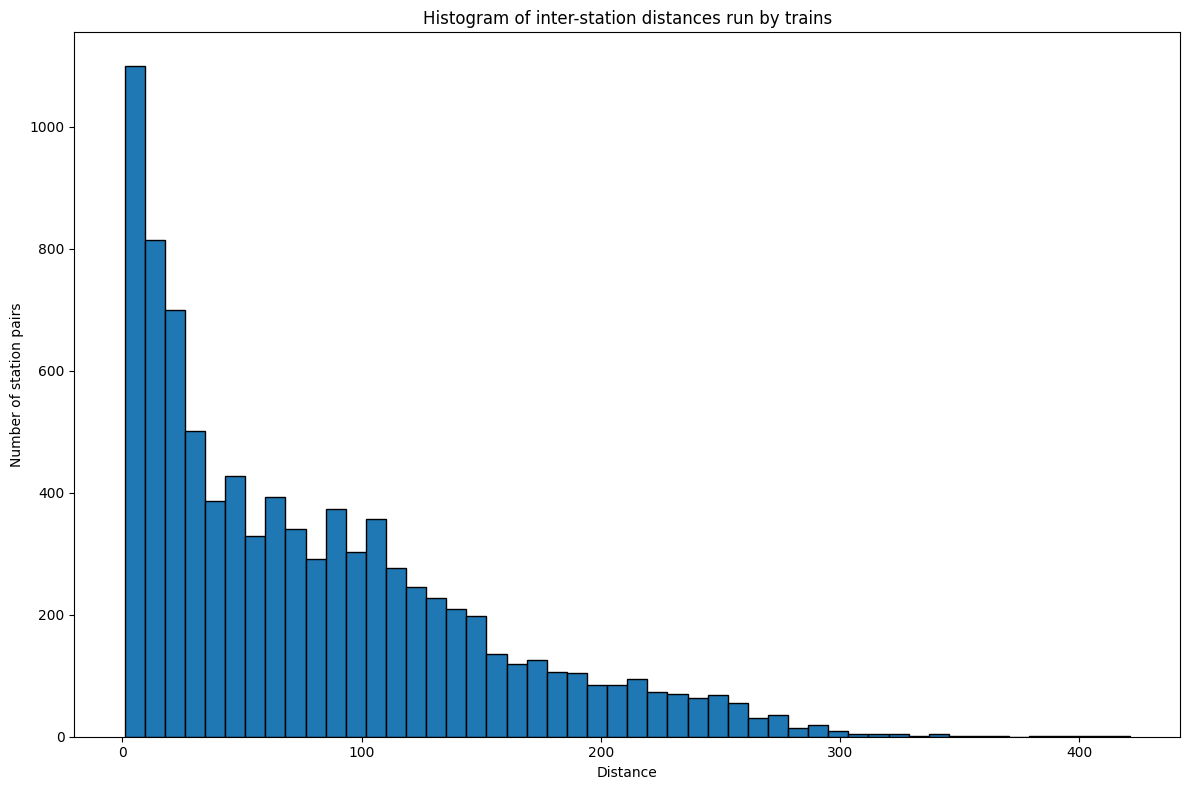

In [26]:
#4
df = db.sql("""
SELECT distance
FROM station_connections
WHERE distance IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(df["distance"], bins=50, edgecolor="black")
ax.set_xlabel("Distance")
ax.set_ylabel("Number of station pairs")
ax.set_title("Histogram of inter-station distances run by trains")
plt.tight_layout()
plt.show()